<a href="https://colab.research.google.com/github/Pamodya-Wijesinghe/Simple-convolutional-neural-network-to-perform-classification/blob/main/simplest_possible_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction
The project starts from the simplest possible model and evolves step by step toward multiclass classification, hidden layers, mini-batch training, and deeper networks.

The model will:

- use all 10 Fashion-MNIST classes
- keep the 784 input pixels
- replace the single output with 10 output neurons
- convert output scores into class probabilities with softmax
- use multiclass cross-entropy loss
- update all weights and biases with gradient descent
- predict the class with the highest probability
- evaluate accuracy on the full Fashion-MNIST test set

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
import pandas as pd

In [2]:

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

train = pd.DataFrame(X_train.reshape(X_train.shape[0], -1))
train.insert(0, "label", y_train)

test = pd.DataFrame(X_test.reshape(X_test.shape[0], -1))
test.insert(0, "label", y_test)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
train.head()

,label,0,1,2,3,4,5,6,7,8,...,774,775,776,777,778,779,780,781,782,783
0,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,0,0,0,...,119,114,130,76,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,3,0,0,0,0,0,0,0,0,33,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
labels = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

In [5]:
# Separate pixels from labels

X = train.drop(columns="label").values
y = train["label"].values

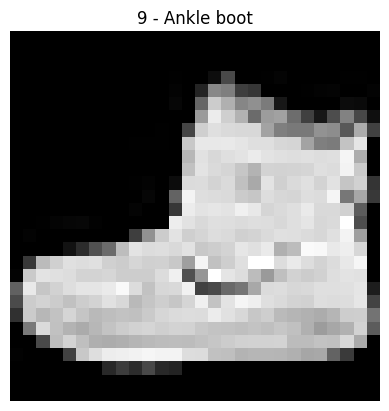

In [6]:
plt.imshow(X[0].reshape(28, 28), cmap="gray")
plt.title(f"{y[0]} - {labels[y[0]]}")
plt.axis("off")
plt.show()

In [7]:
# Normalize pixel values from 0-255 to 0-1

X = X / 255.0

y_onehot = np.eye(10)[y]

## Building the model
We now build a multiclass linear neural network with 10 output neurons.
The softmax function make the output scores into class probabilities which sum to 1.

In [8]:
# Convert raw output scores into class probabilities

def softmax(z):
    exp = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)

In [9]:
def train(X, y, w, b, lr=0.1, tol=1e-4):
    previous_loss = float("inf")

    while True:
        z = X @ w + b
        pred = softmax(z)

        loss = -np.mean(np.sum(y * np.log(pred), axis=1))

        if previous_loss - loss < tol:
            break

        previous_loss = loss

        dw = X.T @ (pred - y) / len(y)
        db = np.mean(pred - y, axis=0)

        w = w - lr * dw
        b = b - lr * db

    return w, b, loss

In [10]:
# Initialize weights and biases for 10 output classes

w = np.zeros((X.shape[1], 10))
b = np.zeros(10)

### Training

The model repeatedly measures its prediction error and updates all weights and biases to reduce the loss.

In [11]:
w, b, loss = train(X, y_onehot, w, b)

print(f"Train loss: {loss:.4f}")

Train loss: 0.5051


## Evaluation

The model predicts the class with the highest probability.

In [12]:
z = X @ w + b
pred = softmax(z)

y_pred = np.argmax(pred, axis=1)
accuracy = np.mean(y_pred == y)

print(f"Train accuracy: {accuracy:.2%}")

Train accuracy: 83.33%


In [13]:
X_test = test.drop(columns="label").values / 255.0
y_test = test["label"].values

pred = softmax(X_test @ w + b)
preds = np.argmax(pred, axis=1)

accuracy = np.mean(preds == y_test)

print(f"Test accuracy: {accuracy:.2%}")

Test accuracy: 82.00%
